In [69]:
import json
import os
import subprocess
import sys
from pathlib import Path
from tempfile import TemporaryDirectory
from urllib.parse import quote

import numpy as np

os.environ["POLARS_OOC_MEMORY_BUDGET_MB"] = "100"  # disable Polars' own memory budget
os.environ["POLARS_ENGINE_AFFINITY"] = "streaming"
os.environ["POLARS_STREAMING_CHUNK_SIZE"] = "2000"  # small chunks to stress memory
os.environ["POLARS_VERBOSE"] = "0"  # enable verbose logging to stdout for debugging
os.environ["POLARS_MAX_THREADS"] = "1"  # enable verbose logging to stdout for debugging

import polars as pl

_IMPL = Path(".").parent / "_memory_analysis_impl.py"
assert _IMPL.exists(), f"Expected {_IMPL} to exist"


def write_partitioned_measurements(src: Path, n_partitions: int, rows_per_partition: int) -> float:
    """Write partitioned parquet with (measurement, unit, timestamp, value) columns.

    Each partition holds ``ROWS_PER_PARTITION`` readings spread over
    ``N_MEASUREMENTS`` distinct measurements, so grouping by measurement yields
    a handful of groups with very long ``timestamp``/``value`` list columns.
    """
    total_mbytes = 0
    for p in range(n_partitions):
        measurement = f"measurement_{p}"
        measurement_col = "measurement"
        partition_dir = src / f"{quote(measurement_col)}={quote(measurement)}"
        partition_dir.mkdir(parents=True, exist_ok=True)
        df = pl.DataFrame([
            pl.repeat(measurement, 10_000, eager=True).rename(measurement_col),
            (pl.int_range(0, 10_000, eager=True) % 5)
            .cast(pl.String)
            .str.pad_start(length=3, fill_char="0")
            .rename("channel"),
            pl.Series(np.random.rand(10_000)).rename("value"),
        ])
        df.write_parquet(partition_dir / "00001.parquet")
        total_mbytes += df.estimated_size(unit="mb")
    return total_mbytes


def _run(name: str, tmp_path: Path, n_partitions: int, rows_per_partition: int) -> dict:
    """Spawn a fresh interpreter to run ``run_<name>`` in ``_memory_analysis_impl.py``."""
    src = tmp_path / "src"
    src.mkdir(parents=True, exist_ok=True)
    data_size_mb = write_partitioned_measurements(src, n_partitions, rows_per_partition)

    result = subprocess.run(
        [
            sys.executable,
            str(_IMPL),
            name,
            str(tmp_path),
            str(rows_per_partition),
        ],
        capture_output=True,
        text=True,
        env={**os.environ},
    )
    output = (result.stdout + result.stderr).strip()
    print(f"Output from memory worker '{name}':\n{output}")

    if result.returncode != 0:
        raise RuntimeError(f"Memory worker '{name}' failed:\n{output}")
    else:
        data = json.loads(output.splitlines()[-1])
        data.update({"dataset_size_mb": data_size_mb})
        return data


rows_per_partition = 100_000
num_partitions = 200

results = []

for i in range(1, num_partitions + 1, 20):
    with TemporaryDirectory() as tmp_dir:
        tmp_path = Path(tmp_dir)
        result = _run("pure_polars", tmp_path, i, rows_per_partition)
        print(
            f"Peak RSS: {result['peak_rss_mb']:.1f} MB, Dataset size: {result['dataset_size_mb']:.1f} MB"
        )

        result.update({"n_partitions": i, "rows_per_partition": rows_per_partition})
        results.append(result)


Output from memory worker 'pure_polars':
{"peak_rss_mb": 0.0}
Peak RSS: 0.0 MB, Dataset size: 0.2 MB
Output from memory worker 'pure_polars':
{"peak_rss_mb": 19.046875}
Peak RSS: 19.0 MB, Dataset size: 4.9 MB
Output from memory worker 'pure_polars':
{"peak_rss_mb": 19.890625}
Peak RSS: 19.9 MB, Dataset size: 9.7 MB
Output from memory worker 'pure_polars':
{"peak_rss_mb": 19.921875}
Peak RSS: 19.9 MB, Dataset size: 14.4 MB
Output from memory worker 'pure_polars':
{"peak_rss_mb": 19.984375}
Peak RSS: 20.0 MB, Dataset size: 19.2 MB
Output from memory worker 'pure_polars':
{"peak_rss_mb": 20.046875}
Peak RSS: 20.0 MB, Dataset size: 24.0 MB
Output from memory worker 'pure_polars':
{"peak_rss_mb": 21.625}
Peak RSS: 21.6 MB, Dataset size: 29.0 MB
Output from memory worker 'pure_polars':
{"peak_rss_mb": 21.515625}
Peak RSS: 21.5 MB, Dataset size: 33.9 MB
Output from memory worker 'pure_polars':
{"peak_rss_mb": 21.671875}
Peak RSS: 21.7 MB, Dataset size: 38.9 MB
Output from memory worker 'pure_

In [70]:
results_df = pl.DataFrame(results)
results_df.unpivot(
    index="n_partitions",
    on=["peak_rss_mb", "dataset_size_mb"],
    variable_name="metric",
    value_name="value",
).plot.line().encode(x="n_partitions", y="value", color="metric")

alt.Chart(...)

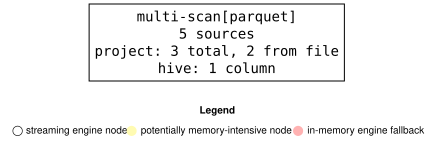

In [71]:
with TemporaryDirectory() as tmp_dir:
    tmp_path = Path(tmp_dir)
    src = tmp_path / "src"
    src.mkdir(parents=True, exist_ok=True)
    data_size_mb = write_partitioned_measurements(src, 5, rows_per_partition)

    lf = pl.scan_parquet(str(src / "**" / "*.parquet"), hive_partitioning=True)
    lf.sink_parquet(
        pl.PartitionBy(
            str(tmp_path / "target"),
            key="measurement",
            # max_rows_per_file=rows_per_partition,
        ),
        lazy=True,
    )
    lf.show_graph(engine="streaming", plan_stage="physical")